In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [40]:
df = pd.read_csv(
    "/Users/tsantaloic/Desktop/Projet_05_AIA02/data/processed/amazon_reviews_cleaned.csv",
    parse_dates=["timestamp"]
)

df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747


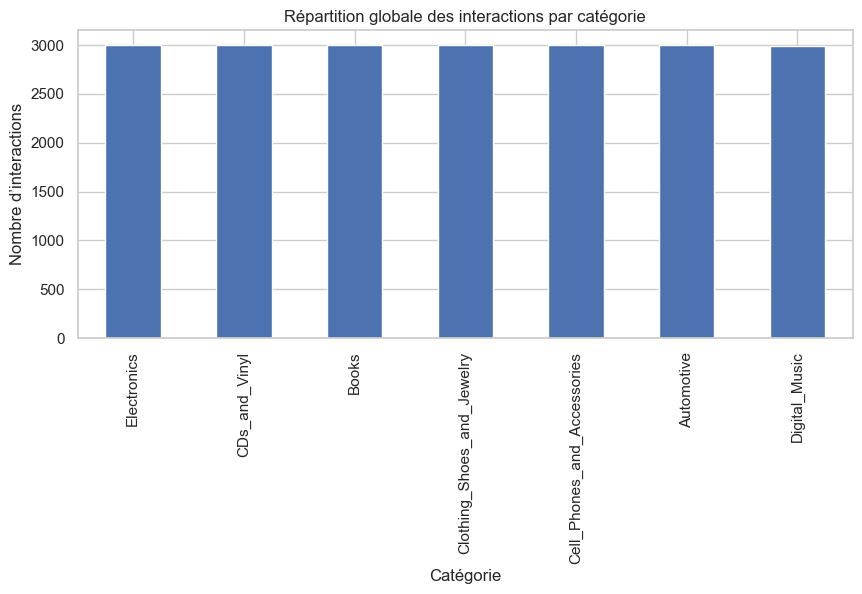

In [41]:
user_category_counts = (
    df.groupby(["user_id", "category"])
      .size()
      .unstack(fill_value=0)
)

user_category_counts.head()

plt.figure(figsize=(10,4))
df["category"].value_counts().plot(kind="bar")
plt.title("Répartition globale des interactions par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d’interactions")
plt.show()



In [42]:
df["category"].value_counts(dropna=False)
df["category"].nunique()


7

In [5]:
user_category_counts.sum().sort_values(ascending=False)


category
Books                          3000
CDs_and_Vinyl                  3000
Cell_Phones_and_Accessories    3000
Clothing_Shoes_and_Jewelry     3000
Electronics                    3000
Automotive                     2999
Digital_Music                  2991
dtype: int64

In [6]:
df["category"] = df["category"].str.strip()  
df["category"].unique()                      


array(['Electronics', 'Automotive', 'CDs_and_Vinyl', 'Books',
       'Digital_Music', 'Clothing_Shoes_and_Jewelry',
       'Cell_Phones_and_Accessories'], dtype=object)

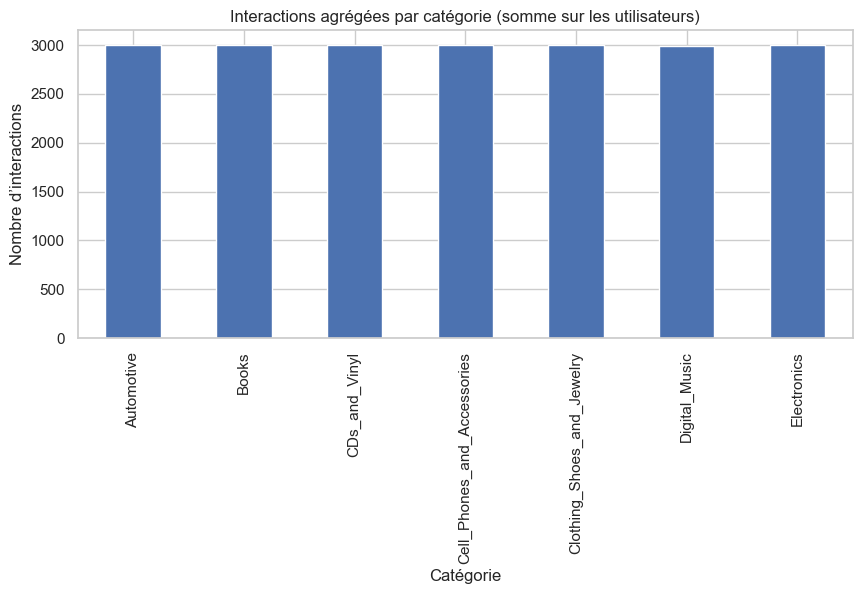

In [7]:
user_category_counts.sum().plot(kind="bar", figsize=(10,4))
plt.title("Interactions agrégées par catégorie (somme sur les utilisateurs)")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d’interactions")
plt.show()


In [8]:
# Bornes & types
assert df["rating"].between(1,5).all()
df["helpful_vote"] = pd.to_numeric(df["helpful_vote"], errors="coerce").fillna(0).astype(int)
df["verified_purchase"] = df["verified_purchase"].astype(bool)


In [9]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20990 entries, 0 to 20989
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   rating             20990 non-null  float64       
 1   title              20990 non-null  object        
 2   text               20990 non-null  object        
 3   images             20990 non-null  object        
 4   asin               20990 non-null  object        
 5   parent_asin        20990 non-null  object        
 6   user_id            20990 non-null  object        
 7   timestamp          20990 non-null  datetime64[ns]
 8   helpful_vote       20990 non-null  int64         
 9   verified_purchase  20990 non-null  bool          
 10  category           20990 non-null  object        
 11  user_id_enc        20990 non-null  int64         
 12  item_id_enc        20990 non-null  int64         
 13  rating_norm        20990 non-null  float64       
dtypes: boo

In [11]:
for col in ["category","asin","parent_asin","user_id","title"]:
    df[col] = df[col].astype(str).str.strip()
df["category"] = df["category"].str.replace(r"\s+", " ", regex=True)


In [12]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747


In [13]:
# audit catégories
cats = df["category"].value_counts(dropna=False)
# éventuelle table de mapping
mapping = {
    "Cell_Phones_and_Accessories": "Cell_Phones_and_Accessories",
    # ajouter si variantes détectées
}
df["category"] = df["category"].map(mapping).fillna(df["category"])


In [14]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747


In [15]:
# doublons stricts
df = df.drop_duplicates(subset=["user_id","asin","timestamp","text"])
# clés vides
assert df["user_id"].ne("").all() and df["asin"].ne("").all()


In [16]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747


In [17]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
assert df["timestamp"].notna().all()


In [18]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948000+00:00,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731000+00:00,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534000+00:00,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35+00:00,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238000+00:00,0,True,Electronics,1892,12523,0.557747


In [19]:
import re, unicodedata
def clean_text(s):
    s = str(s)
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s
df["text"] = df["text"].map(clean_text)


In [20]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948000+00:00,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731000+00:00,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534000+00:00,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35+00:00,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238000+00:00,0,True,Electronics,1892,12523,0.557747


In [21]:
missing = df.isna().sum().sort_values(ascending=False)
# outliers votes
assert (df["helpful_vote"] >= 0).all()


In [22]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948000+00:00,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731000+00:00,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534000+00:00,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35+00:00,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238000+00:00,0,True,Electronics,1892,12523,0.557747


In [23]:

# Comptage par user et catégorie
user_category_counts = (
    df
    .groupby(["user_id", "category"])
    .size()
    .rename("count")
    .reset_index()
)

# Total par user
user_totals = user_category_counts.groupby("user_id")["count"].transform("sum")

# Proportions
user_category_counts["p"] = user_category_counts["count"] / user_totals



In [24]:
# Matrice utilisateur x catégorie (proportions)
user_category_matrix = (
    user_category_counts
    .pivot_table(index="user_id", columns="category", values="p", fill_value=0)
)

# Features (1 ligne par user)
user_category_props = pd.DataFrame({"user_id": user_category_matrix.index})

user_category_props["favorite_category"] = user_category_matrix.idxmax(axis=1).values
user_category_props["favorite_category_share"] = user_category_matrix.max(axis=1).values

def entropy_row(row):
    p = row[row > 0]
    return -(p * np.log2(p)).sum()

user_category_props["category_entropy"] = user_category_matrix.apply(entropy_row, axis=1).values

user_category_props.head()


,user_id,favorite_category,favorite_category_share,category_entropy
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,Digital_Music,1.0,-0.0
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,Digital_Music,1.0,-0.0
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,Cell_Phones_and_Accessories,1.0,-0.0
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,Automotive,1.0,-0.0
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,Electronics,1.0,-0.0


In [25]:
user_category_props.head()
user_category_props.columns.tolist()


['user_id', 'favorite_category', 'favorite_category_share', 'category_entropy']

In [27]:

sample_users = user_category_matrix.sample(20, random_state=42)
sample_users.head()


category,Automotive,Books,CDs_and_Vinyl,Cell_Phones_and_Accessories,Clothing_Shoes_and_Jewelry,Digital_Music,Electronics
user_id,,,,,,,
AHRY6RC5I37JOTY2CRKYVARAQ27A,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
AF3HNAQK2URNEBAZQCRZGSPBU5FQ,0.074074,0.851852,0.000000,0.037037,0.000000,0.0,0.037037
AHAR2ITQ3O2FJJDLIORAQ226KZHQ,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
AFODRXNLEQI45IJTZOSHP2H2AMMQ,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
AGMKOM3374MIOS47KXTIFEGAFKOQ,0.000000,0.000000,0.111111,0.000000,0.777778,0.0,0.111111


In [28]:
# Aperçu des features calculées
user_category_props[["user_id","favorite_category","favorite_category_share","category_entropy"]].head()

# Sauvegarde pour réutilisation dans d'autres notebooks
user_category_props.to_csv("../data/processed/user_category_entropy.csv", index=False)



In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20990 entries, 0 to 20989
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   rating             20990 non-null  float64            
 1   title              20990 non-null  object             
 2   text               20990 non-null  object             
 3   images             20990 non-null  object             
 4   asin               20990 non-null  object             
 5   parent_asin        20990 non-null  object             
 6   user_id            20990 non-null  object             
 7   timestamp          20990 non-null  datetime64[ns, UTC]
 8   helpful_vote       20990 non-null  int64              
 9   verified_purchase  20990 non-null  bool               
 10  category           20990 non-null  object             
 11  user_id_enc        20990 non-null  int64              
 12  item_id_enc        20990 non-null  int64      

In [30]:
df["timestamp"] = df["timestamp"].dt.tz_convert(None)


In [31]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747


In [32]:
df["helpful_vote_log"] = np.log1p(df["helpful_vote"])


In [33]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm,helpful_vote_log
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889,0.000000
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525,0.000000
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747,0.000000
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747,2.944439
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747,0.000000


In [34]:

user_category_props["category_entropy"].describe()


count    3777.000000
mean        0.246835
std         0.506113
min        -0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.355474
Name: category_entropy, dtype: float64

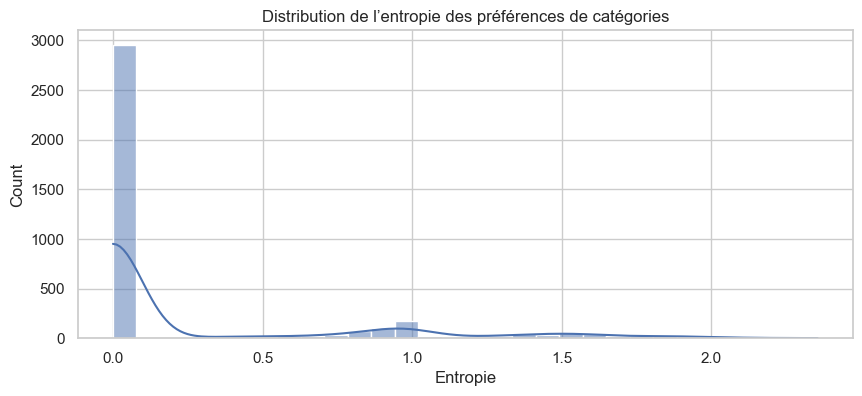

In [35]:
plt.figure(figsize=(10,4))
sns.histplot(user_category_props["category_entropy"], bins=30, kde=True)
plt.title("Distribution de l’entropie des préférences de catégories")
plt.xlabel("Entropie")
plt.show()


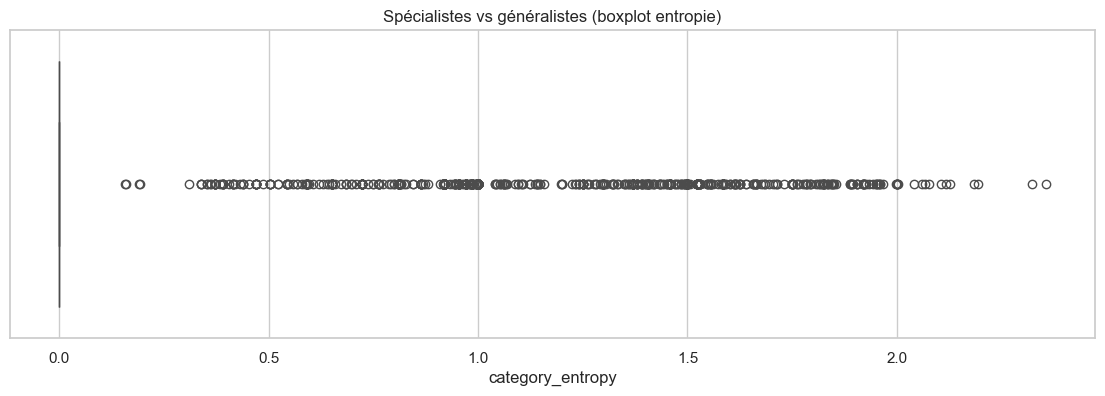

In [36]:
plt.figure(figsize=(14,4))
sns.boxplot(x=user_category_props["category_entropy"])
plt.title("Spécialistes vs généralistes (boxplot entropie)")
plt.show()


In [37]:
user_category_props.head()
user_category_props.columns.tolist()


['user_id', 'favorite_category', 'favorite_category_share', 'category_entropy']

In [38]:
df.to_csv("../data/processed/user_category_features.csv", index=False)
